# Do Street Lamps Affect Crashes in Philly

<img src="img/crash.jpeg" width="450" style="display:block; margin:auto;">

With a significant number of vehicular crashes happening across Philly every year, it is important to consider different factors that could help reduce the prevelance of such incidents. One variable that should be considered is the presence of street lamps across Philly. An increase in the number fo street lamps could potentially help reduce the number of traffic incidents at night by allowing for greater visibility for drivers.

### Loading the Data

In [2]:
import pandas as pd
import geopandas as gpd
import numpy as np
import camelot
import calendar
import re
import matplotlib.pyplot as plt

In [3]:
crash_data = pd.read_csv('data/PDOT_crash_data_2005_2024.csv', low_memory=False)
street_pole_data = gpd.read_file('data/Street_Poles.geojson')
crash_data = crash_data[crash_data["COUNTY"] == 67]

### Observing the Location of the Crashes in relation to the street lamps

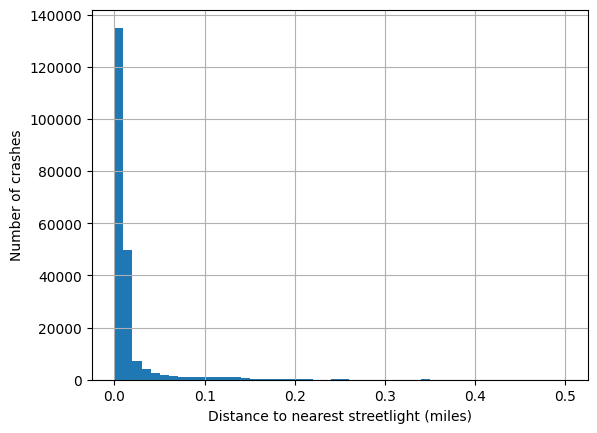

In [20]:
crash_data_clean = crash_data.dropna(subset=["DEC_LONGITUDE", "DEC_LATITUDE"])
crash_data_clean = crash_data_clean[
    (crash_data_clean["DEC_LONGITUDE"] != 0) &
    (crash_data_clean["DEC_LATITUDE"] != 0)
]

lights = gpd.read_file('data/Street_Poles.geojson')

crashes = gpd.GeoDataFrame(
    crash_data_clean,
    geometry=gpd.points_from_xy(
        crash_data_clean["DEC_LONGITUDE"],
        crash_data_clean["DEC_LATITUDE"],
    ),
    crs="EPSG:4326"
)

crashes_m = crashes.to_crs(epsg=3857)
lights_m = lights.to_crs(epsg=3857)

joined = gpd.sjoin_nearest(
    crashes_m,
    lights_m,
    how="left",
    distance_col="dist_to_light"
)

joined["dist_to_light"] = joined["dist_to_light"] / 1609.34


joined["dist_to_light"].hist(bins=50, range=(0, 0.5))
plt.xlabel("Distance to nearest streetlight (miles)")
plt.ylabel("Number of crashes")
plt.show()

From the chart above, we can observe that most crashes observe within 0.03 miles of a traffic light with a limited number of outliers occuring far outside that range. This can mostly be attributed to the large presence of street lamps across the city which means that all crashes are almost guaranteed to occur next to a street lamp.

### Comparing Daytime and Nightime Crashes

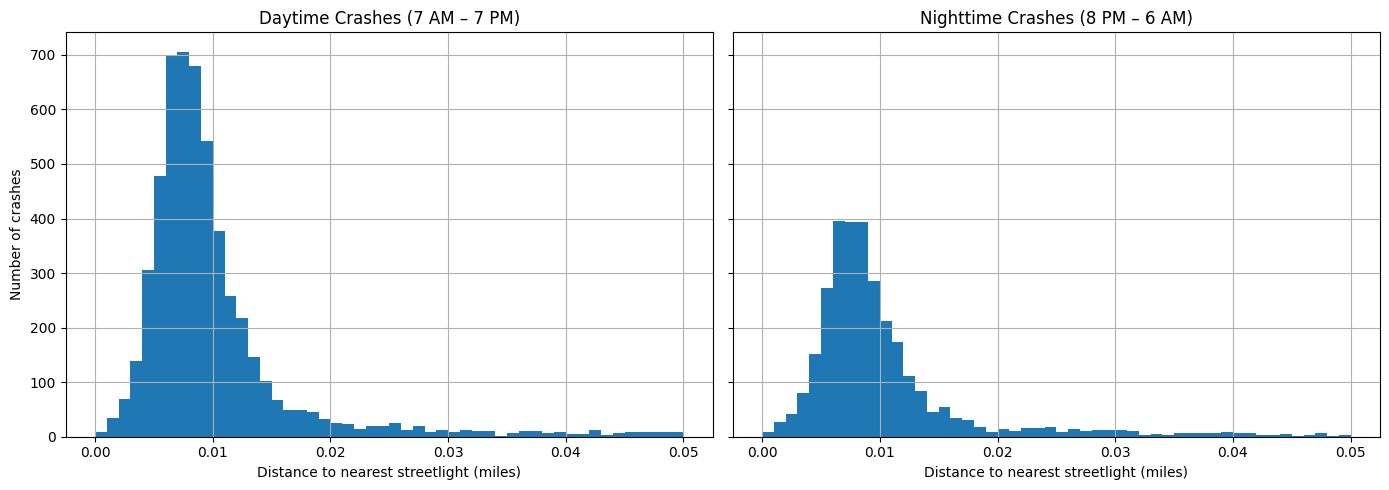

In [22]:
night = joined[(joined["HOUR_OF_DAY"] >= 20) | (joined["HOUR_OF_DAY"] <= 6)]
day = joined[(joined["HOUR_OF_DAY"] > 6) & (joined["HOUR_OF_DAY"] < 20)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

day["dist_to_light"].hist(bins=50, range=(0, 0.05), ax=axes[0])
axes[0].set_title("Daytime Crashes (7 AM – 7 PM)")
axes[0].set_xlabel("Distance to nearest streetlight (miles)")
axes[0].set_ylabel("Number of crashes")

night["dist_to_light"].hist(bins=50, range=(0, 0.05), ax=axes[1])
axes[1].set_title("Nighttime Crashes (8 PM – 6 AM)")
axes[1].set_xlabel("Distance to nearest streetlight (miles)")

plt.tight_layout()
plt.show()

From the charts above, we can further observe that the distribution of the distance of vehicular crashes from the nearest street lamp follows roughly the same distribution during both the day and night. Once again, this would be attributed to the huge presence of street lamps across the city meaning most car accidents would happen next to one. This means that we are unable to conclude if street lamps are actually effective in preventing car accidents at night time.